## Description of Variables in House Price Dataset
 It helps understand the meaning of each feature before preprocessing or modeling
 
| Variable    | Description |
|-------------|-------------|
| crime_rate  | Crime level in the area, Higher values indicate more crime. |
| resid_area  | Residential land area used for housing. |
| air_qual    | Air pollution level, Higher values indicate worse air quality. |
| age         | Proportion of older houses in the area. |
| rainfall    | Average rainfall in the area. |
| waterbody   | Type of nearby water body (river, lake, etc.). |
| parks       | Proportion of green space in the area. |
| room_num    | Average number of rooms per house. |
| n_hos_beds  | Number of hospital beds in the area. |
| n_hot_rooms | Number of hotel rooms (tourism indicator). |
| dist1       | Distance to the nearest employment center. |
| dist2       | Distance to the second employment center. |
| dist3       | Distance to the third employment center. |
| dist4       | Distance to the fourth employment center. |
| bus_ter     | Indicates whether a bus terminal is nearby (YES/NO). |
| airport     | Indicates whether an airport is nearby (YES/NO). |
| teachers    | Number of teachers in the area (education indicator). |
| poor_prop   | Proportion of population considered poor. |

## Exploratory Data Analysis (EDA) 

In [326]:
#IMPORT LIBRARIES 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [327]:
df = pd.read_csv("House_Price.csv")

In [328]:
print(f'Shape: {df.shape}')

Shape: (506, 19)


In [ ]:
df.head()

,price,crime_rate,resid_area,air_qual,room_num,age,dist1,dist2,dist3,dist4,teachers,poor_prop,airport,n_hos_beds,n_hot_rooms,waterbody,rainfall,bus_ter,parks
0,24.0,0.00632,32.31,0.538,6.575,65.2,4.35,3.81,4.18,4.01,24.7,4.98,YES,5.480,11.1920,River,23,YES,0.049347
1,21.6,0.02731,37.07,0.469,6.421,78.9,4.99,4.70,5.12,5.06,22.2,9.14,NO,7.332,12.1728,Lake,42,YES,0.046146
2,34.7,0.02729,37.07,0.469,7.185,61.1,5.03,4.86,5.01,4.97,22.2,4.03,NO,7.394,101.1200,NaN,38,YES,0.045764
3,33.4,0.03237,32.18,0.458,6.998,45.8,6.21,5.93,6.16,5.96,21.3,2.94,YES,9.268,11.2672,Lake,45,YES,0.047151
4,36.2,0.06905,32.18,0.458,7.147,54.2,6.16,5.86,6.37,5.86,21.3,5.33,NO,8.824,11.2896,Lake,55,YES,0.039474


In [330]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   price        506 non-null    float64
 1   crime_rate   506 non-null    float64
 2   resid_area   506 non-null    float64
 3   air_qual     506 non-null    float64
 4   room_num     506 non-null    float64
 5   age          506 non-null    float64
 6   dist1        506 non-null    float64
 7   dist2        506 non-null    float64
 8   dist3        506 non-null    float64
 9   dist4        506 non-null    float64
 10  teachers     506 non-null    float64
 11  poor_prop    506 non-null    float64
 12  airport      506 non-null    object 
 13  n_hos_beds   498 non-null    float64
 14  n_hot_rooms  506 non-null    float64
 15  waterbody    351 non-null    object 
 16  rainfall     506 non-null    int64  
 17  bus_ter      506 non-null    object 
 18  parks        506 non-null    float64
dtypes: float

In [331]:
df.describe()

,price,crime_rate,resid_area,air_qual,room_num,age,dist1,dist2,dist3,dist4,teachers,poor_prop,n_hos_beds,n_hot_rooms,rainfall,parks
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,498.000000,506.000000,506.000000,506.000000
mean,22.528854,3.613524,41.136779,0.554695,6.284634,68.574901,3.971996,3.628775,3.960672,3.618972,21.544466,12.653063,7.899767,13.041605,39.181818,0.054454
std,9.182176,8.601545,6.860353,0.115878,0.702617,28.148861,2.108532,2.108580,2.119797,2.099203,2.164946,7.141062,1.476683,5.238957,12.513697,0.010632
min,5.000000,0.006320,30.460000,0.385000,3.561000,2.900000,1.130000,0.920000,1.150000,0.730000,18.000000,1.730000,5.268000,10.057600,3.000000,0.033292
25%,17.025000,0.082045,35.190000,0.449000,5.885500,45.025000,2.270000,1.940000,2.232500,1.940000,19.800000,6.950000,6.634500,11.189800,28.000000,0.046464
50%,21.200000,0.256510,39.690000,0.538000,6.208500,77.500000,3.385000,3.010000,3.375000,3.070000,20.950000,11.360000,7.999000,12.720000,39.000000,0.053507
75%,25.000000,3.677083,48.100000,0.624000,6.623500,94.075000,5.367500,4.992500,5.407500,4.985000,22.600000,16.955000,9.088000,14.170800,50.000000,0.061397
max,50.000000,88.976200,57.740000,0.871000,8.780000,100.000000,12.320000,11.930000,12.320000,11.940000,27.400000,37.970000,10.876000,101.120000,60.000000,0.086711


In [332]:
df.duplicated().sum()

np.int64(0)

In [333]:
df.isnull().sum()

price            0
crime_rate       0
resid_area       0
air_qual         0
room_num         0
age              0
dist1            0
dist2            0
dist3            0
dist4            0
teachers         0
poor_prop        0
airport          0
n_hos_beds       8
n_hot_rooms      0
waterbody      155
rainfall         0
bus_ter          0
parks            0
dtype: int64

In [334]:
#Rename Column Names

df.rename(columns={
 'n_hos_beds': 'hospital_beds',
 'n_hot_rooms': 'hotel_rooms',
 'poor_prop': 'poverty_rate',
 'bus_ter': 'has_bus_terminal',
}, inplace=True)
df.columns.tolist()

['price',
 'crime_rate',
 'resid_area',
 'air_qual',
 'room_num',
 'age',
 'dist1',
 'dist2',
 'dist3',
 'dist4',
 'teachers',
 'poverty_rate',
 'airport',
 'hospital_beds',
 'hotel_rooms',
 'waterbody',
 'rainfall',
 'has_bus_terminal',
 'parks']

In [335]:
# Separating numerical and categorical features for proper preprocessing steps

numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: Index(['price', 'crime_rate', 'resid_area', 'air_qual', 'room_num', 'age',
       'dist1', 'dist2', 'dist3', 'dist4', 'teachers', 'poverty_rate',
       'hospital_beds', 'hotel_rooms', 'rainfall', 'parks'],
      dtype='object')
Categorical Columns: Index(['airport', 'waterbody', 'has_bus_terminal'], dtype='object')


## Train / Test Split

 Splitting the dataset into training and testing set to evaluate model performance on unseen data

In [336]:
X = df.drop('price', axis=1)
y = df['price']

In [337]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Preprocessing
## Handling Missing Values

In [338]:
#  Numerical features → replaced with median

num_cols = X_train.select_dtypes(include='number').columns

medians = X_train[num_cols].median()

X_train[num_cols] = X_train[num_cols].fillna(medians)
X_test[num_cols] = X_test[num_cols].fillna(medians)

In [339]:
# Categorical features → replaced with mode

cat_cols = X_train.select_dtypes(exclude='number').columns

modes = X_train[cat_cols].mode().iloc[0]

X_train[cat_cols] = X_train[cat_cols].fillna(modes)
X_test[cat_cols] = X_test[cat_cols].fillna(modes)

In [340]:
X_train.isnull().sum()

crime_rate          0
resid_area          0
air_qual            0
room_num            0
age                 0
dist1               0
dist2               0
dist3               0
dist4               0
teachers            0
poverty_rate        0
airport             0
hospital_beds       0
hotel_rooms         0
waterbody           0
rainfall            0
has_bus_terminal    0
parks               0
dtype: int64

In [341]:
# After handle
X_test.isnull().sum()

crime_rate          0
resid_area          0
air_qual            0
room_num            0
age                 0
dist1               0
dist2               0
dist3               0
dist4               0
teachers            0
poverty_rate        0
airport             0
hospital_beds       0
hotel_rooms         0
waterbody           0
rainfall            0
has_bus_terminal    0
parks               0
dtype: int64

##  Encoding Categorical Variables

 Converting categorical variables into numerical format using One-Hot Encoding, This is necessary for machine learning models to process categorical data

In [342]:
X_train['waterbody'].unique()

array(['Lake', 'River', 'Lake and River'], dtype=object)

In [343]:
X_train['airport'].unique()

array(['NO', 'YES'], dtype=object)

In [ ]:
X_train['has_bus_terminal'].unique()

array(['YES'], dtype=object)

In [345]:
# This column has only one value (no information)

X_train.drop('has_bus_terminal', axis=1, inplace=True)
X_test.drop('has_bus_terminal', axis=1, inplace=True)

In [346]:
cat_cols = ['waterbody', 'airport']

X_train = pd.get_dummies(X_train, columns=cat_cols, dtype=int)
X_test = pd.get_dummies(X_test, columns=cat_cols, dtype=int)

In [347]:
# Align train and test sets to ensure they have the same columns
# This avoids mismatch errors after one-hot encoding

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [348]:
X_train.head()

,crime_rate,resid_area,air_qual,room_num,age,dist1,dist2,dist3,dist4,teachers,poverty_rate,hospital_beds,hotel_rooms,rainfall,parks,waterbody_Lake,waterbody_Lake and River,waterbody_River,airport_NO,airport_YES
477,15.02340,48.10,0.6140,5.304,97.3,2.28,1.99,2.41,1.73,19.8,24.91,9.340,15.0960,39,0.061922,1,0,0,1,0
15,0.62739,38.14,0.5380,5.834,56.5,4.60,4.35,4.72,4.32,19.0,8.47,8.498,14.1592,28,0.059751,0,0,1,0,1
332,0.03466,36.06,0.4379,6.031,23.3,6.95,6.58,6.80,6.23,23.1,7.83,7.488,14.1552,22,0.051756,0,0,1,0,1
423,7.05042,48.10,0.6140,6.103,85.1,2.08,1.80,2.34,1.87,19.8,23.29,8.268,81.1200,29,0.063344,1,0,0,1,0
19,0.72580,38.14,0.5380,5.727,69.5,3.98,3.65,4.00,3.57,19.0,11.28,8.564,12.1456,27,0.057770,0,1,0,1,0


##   Outliers or anomalous entries


In [ ]:
num_cols = X_train.select_dtypes(include='number').columns

num_cols = [col for col in num_cols if X_train[col].nunique() > 2]

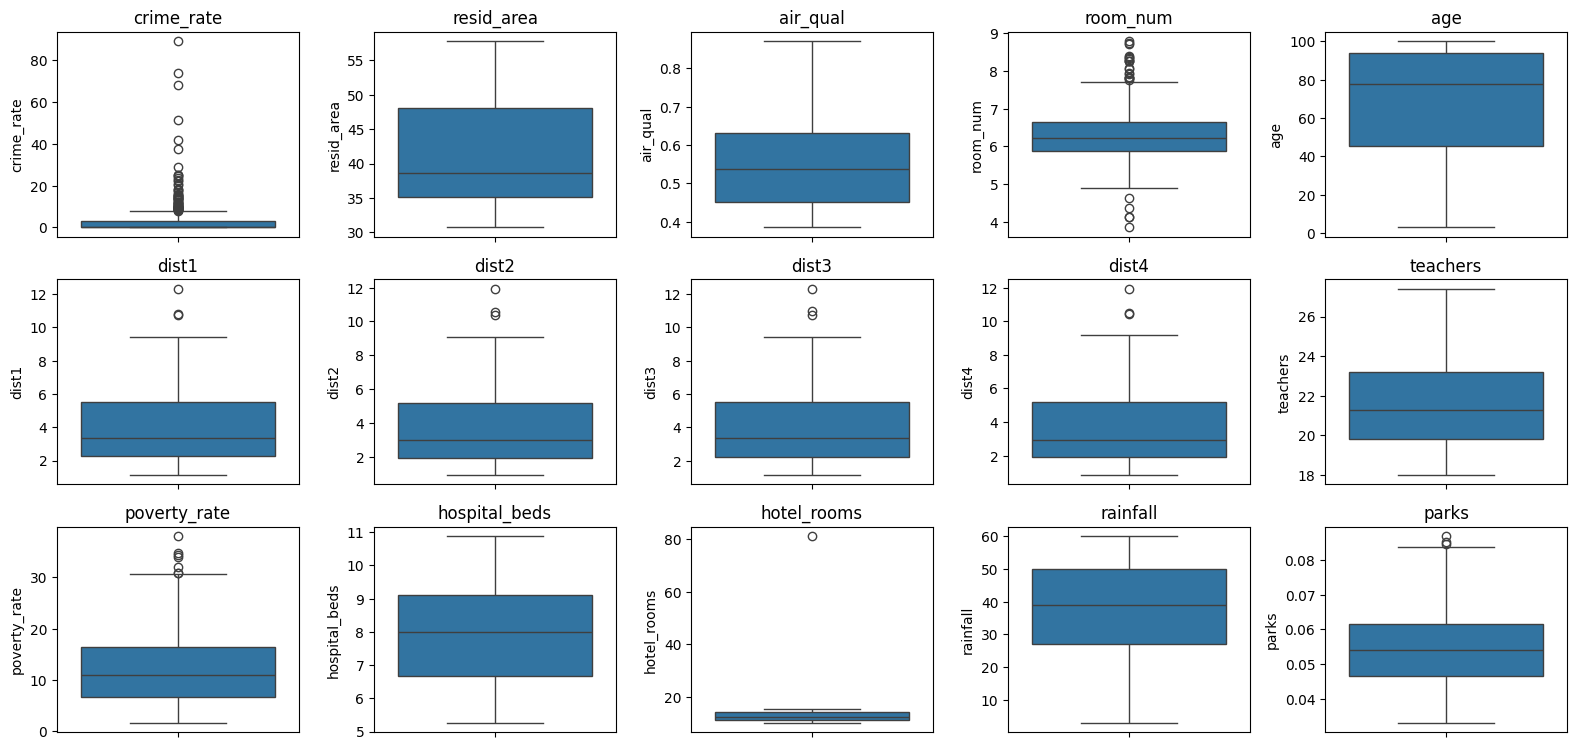

In [350]:
# To Show Outliers

plt.figure(figsize=(16, 10))

for i, col in enumerate(num_cols):
    plt.subplot(4, 5, i+1)
    sns.boxplot(y=X_train[col])
    plt.title(col)

plt.tight_layout()
plt.show()

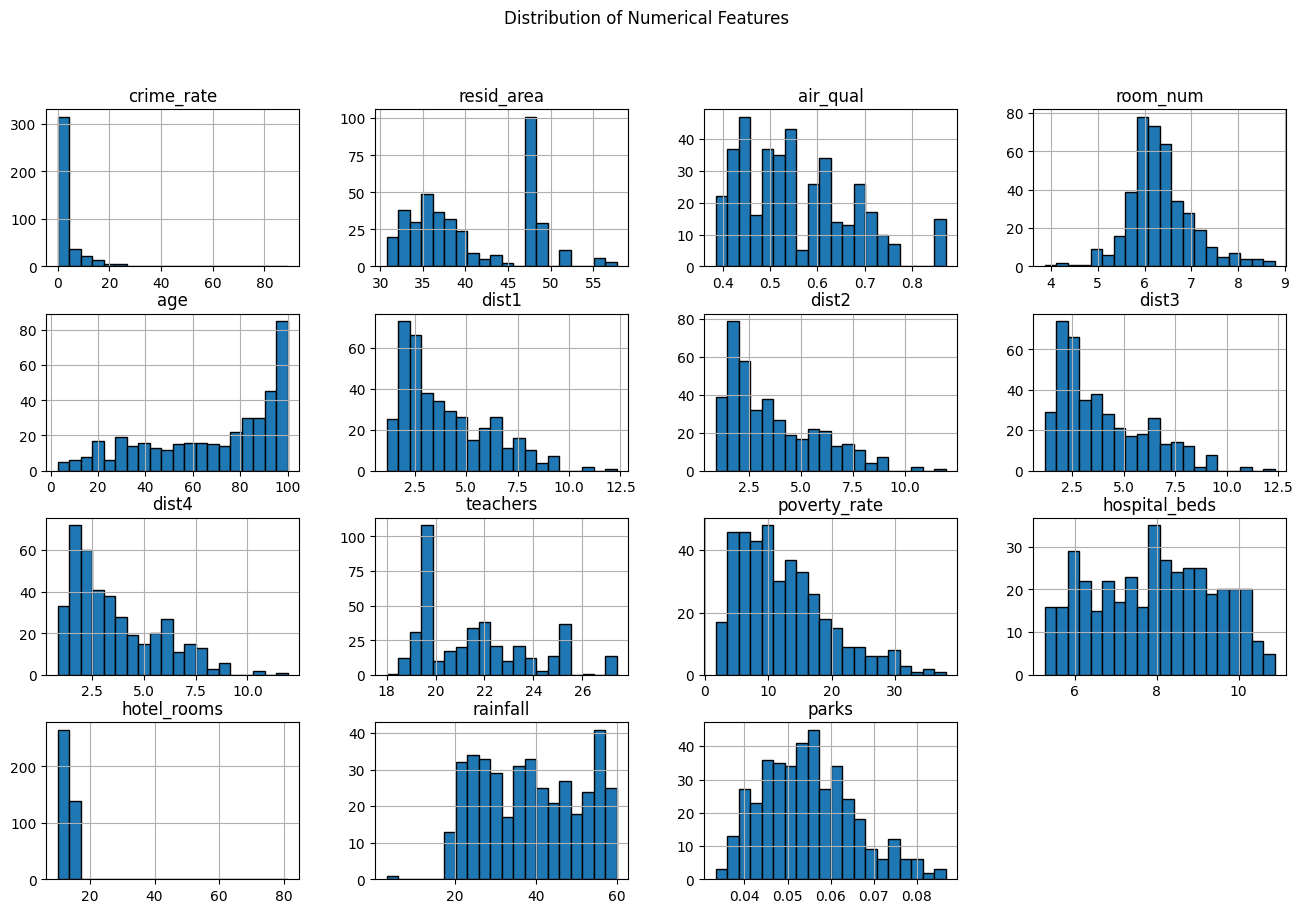

In [351]:
X_train[num_cols].hist(figsize=(16, 10), bins=20, edgecolor='black')
plt.suptitle("Distribution of Numerical Features")
plt.show()

In [352]:
# To Show Outliers in Continous Coulmns

Q1 = X_train[num_cols].quantile(0.25)
Q3 = X_train[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_count = ((X_train[num_cols] < lower) | (X_train[num_cols] > upper)).sum()

print(outliers_count.sort_values(ascending=False))

crime_rate       61
room_num         24
poverty_rate      7
dist2             3
dist4             3
dist3             3
dist1             3
parks             3
hotel_rooms       1
resid_area        0
air_qual          0
age               0
teachers          0
hospital_beds     0
rainfall          0
dtype: int64


In [353]:
# Select only continuous numeric columns (exclude binary)
num_cols = [col for col in X_train.columns if X_train[col].nunique() > 2]

# Compute IQR
Q1 = X_train[num_cols].quantile(0.25)
Q3 = X_train[num_cols].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Apply clipping
X_train[num_cols] = X_train[num_cols].clip(lower, upper, axis=1)
X_test[num_cols] = X_test[num_cols].clip(lower, upper, axis=1)

In [354]:
# Outliers in each coulmn

Q1 = X_train[num_cols].quantile(0.25)
Q3 = X_train[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_count = ((X_train[num_cols] < lower) | (X_train[num_cols] > upper)).sum()

print(outliers_count.sort_values(ascending=False))

crime_rate       0
resid_area       0
air_qual         0
room_num         0
age              0
dist1            0
dist2            0
dist3            0
dist4            0
teachers         0
poverty_rate     0
hospital_beds    0
hotel_rooms      0
rainfall         0
parks            0
dtype: int64


##   Redundant / Irrelevant Columns

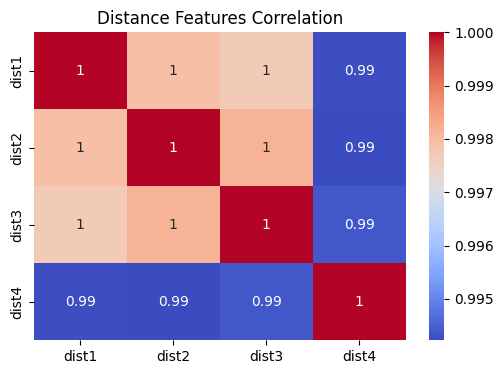

In [355]:
# Visualizing correlation between distance features only
# to detect multicollinearity and redundancy

dist_cols = ['dist1','dist2','dist3','dist4']

plt.figure(figsize=(6,4))
sns.heatmap(X_train[dist_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Distance Features Correlation")
plt.show()

## <mark>Explain</mark>
We performed this step to check for multicollinearity among the distance features (dist1, dist2, dist3, dist4).
We identified whether these features are highly similar or contain redundant information.

If there is a strong correlation between them, it means some of these variables are redundant and do not add new information to the model.

This is important because multicollinearity can make regression models unstable, leading to unreliable coefficient estimates and affecting model interpretability and performance.

In [356]:
# Create a single feature representing average distance because dist1, dist2, dist3, dist4 are highly correlated (0.99-1.0)

X_train['avg_dist'] = X_train[['dist1','dist2','dist3','dist4']].mean(axis=1)
X_test['avg_dist'] = X_test[['dist1','dist2','dist3','dist4']].mean(axis=1)

# Drop original redundant features
X_train.drop(['dist1','dist2','dist3','dist4'], axis=1, inplace=True)
X_test.drop(['dist1','dist2','dist3','dist4'], axis=1, inplace=True)

In [357]:
X_train.head()

,crime_rate,resid_area,air_qual,room_num,age,teachers,poverty_rate,hospital_beds,hotel_rooms,rainfall,parks,waterbody_Lake,waterbody_Lake and River,waterbody_River,airport_NO,airport_YES,avg_dist
477,7.88525,48.10,0.6140,5.304,97.3,19.8,24.91,9.340,15.0960,39,0.061922,1,0,0,1,0,2.1025
15,0.62739,38.14,0.5380,5.834,56.5,19.0,8.47,8.498,14.1592,28,0.059751,0,0,1,0,1,4.4975
332,0.03466,36.06,0.4379,6.031,23.3,23.1,7.83,7.488,14.1552,22,0.051756,0,0,1,0,1,6.6400
423,7.05042,48.10,0.6140,6.103,85.1,19.8,23.29,8.268,18.6441,29,0.063344,1,0,0,1,0,2.0225
19,0.72580,38.14,0.5380,5.727,69.5,19.0,11.28,8.564,12.1456,27,0.057770,0,1,0,1,0,3.8000


In [358]:
# Drop one of the binary dummy variables to avoid multicollinearity
# because airport_NO + airport_YES = 1 (perfect correlation)

X_train.drop('airport_NO', axis=1, inplace=True)
X_test.drop('airport_NO', axis=1, inplace=True)

In [359]:
X_train.head()

,crime_rate,resid_area,air_qual,room_num,age,teachers,poverty_rate,hospital_beds,hotel_rooms,rainfall,parks,waterbody_Lake,waterbody_Lake and River,waterbody_River,airport_YES,avg_dist
477,7.88525,48.10,0.6140,5.304,97.3,19.8,24.91,9.340,15.0960,39,0.061922,1,0,0,0,2.1025
15,0.62739,38.14,0.5380,5.834,56.5,19.0,8.47,8.498,14.1592,28,0.059751,0,0,1,1,4.4975
332,0.03466,36.06,0.4379,6.031,23.3,23.1,7.83,7.488,14.1552,22,0.051756,0,0,1,1,6.6400
423,7.05042,48.10,0.6140,6.103,85.1,19.8,23.29,8.268,18.6441,29,0.063344,1,0,0,0,2.0225
19,0.72580,38.14,0.5380,5.727,69.5,19.0,11.28,8.564,12.1456,27,0.057770,0,1,0,0,3.8000


 Correlation Heatmap Analysis This heatmap is used to understand the relationship between all numerical features and the target variable (price). It helps in identifying the most important features that have strong positive or negative correlation with house prices. Based on this analysis, we will select the most relevant feature(s) to be used in the models.

In [360]:
## Analyzing correlation between features and target variable (price) to identify the most important predictors for modeling

train_df = X_train.copy()
train_df['price'] = y_train

corr_with_price = train_df.corr(numeric_only=True)['price'].sort_values(ascending=False)

print("Top Positive Correlations:")
print(corr_with_price.head(10))

print("\nTop Negative Correlations:")
print(corr_with_price.tail(10))

Top Positive Correlations:
price                       1.000000
room_num                    0.713069
teachers                    0.488105
avg_dist                    0.234825
airport_YES                 0.162139
hospital_beds               0.086741
waterbody_Lake              0.056446
hotel_rooms                -0.005329
waterbody_Lake and River   -0.018698
waterbody_River            -0.034579
Name: price, dtype: float64

Top Negative Correlations:
hotel_rooms                -0.005329
waterbody_Lake and River   -0.018698
waterbody_River            -0.034579
rainfall                   -0.049838
age                        -0.340479
parks                      -0.375578
air_qual                   -0.416781
crime_rate                 -0.458953
resid_area                 -0.471009
poverty_rate               -0.747695
Name: price, dtype: float64


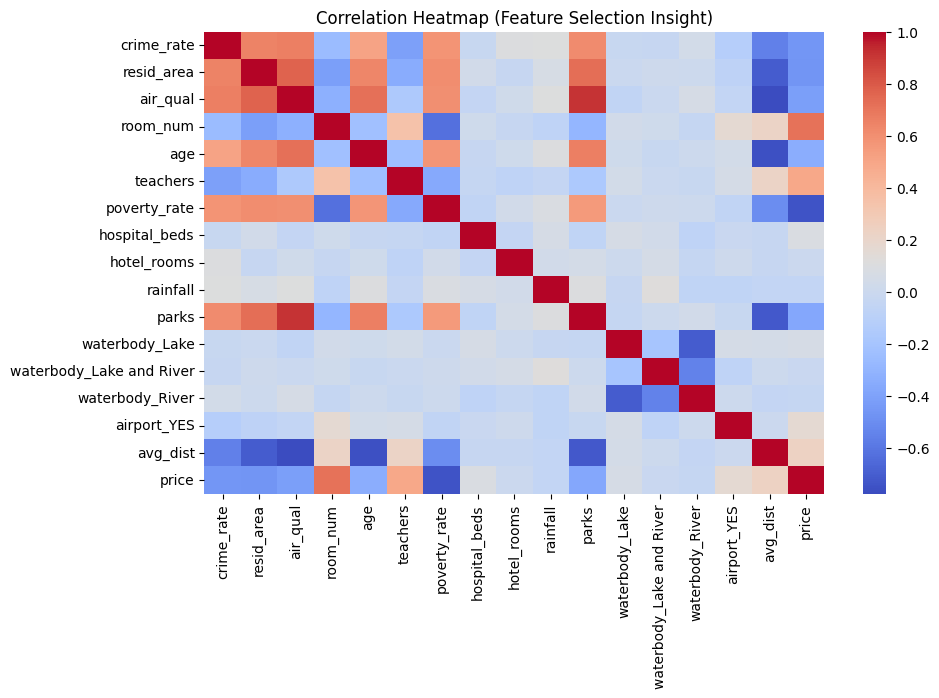

In [361]:
plt.figure(figsize=(10,6))
sns.heatmap(train_df.corr(numeric_only=True), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap (Feature Selection Insight)")
plt.show()

## <mark>Explain</mark>

To examine the relationship between all features and the target variable in general.
 we gain from this:
We identified the most important variables that have a strong relationship with the target.

We also discovered features that are weak or have almost no impact.

This helps in performing initial feature selection before building the model.

## Numerical View – Simple Linear Regression (with Ridge/Lasso)
## y=B0​+B1​x

In [ ]:
class SimpleLinearRegressionNumericalView:

    def __init__(self, regularization=None, alpha=0.0):
        """
        regularization: None | 'ridge' | 'lasso'
        alpha: strength of regularization
        """
        self.B0 = 0
        self.B1 = 0
        self.regularization = regularization
        self.alpha = alpha

        self.SSE = None
        self.MSE = None

    def predict(self, X):
        X = np.array(X).reshape(-1)
        return self.B0 + self.B1 * X

    def compute_sse(self, y, y_hat):
        return np.sum((y - y_hat) ** 2)

    def fit(self, X, y, lr=0.001, epochs=1000):

        X = np.array(X).reshape(-1)
        y = np.array(y).reshape(-1)

        n = len(X)

        for _ in range(epochs):

            y_hat = self.B0 + self.B1 * X
            error = y - y_hat

            dB0 = (-2/n) * np.sum(error)
            dB1 = (-2/n) * np.sum(error * X)

            
            # Ridge (L2)
           
            if self.regularization == "ridge":
                dB1 += 2 * self.alpha * self.B1

           
            # Lasso (L1)
            
            elif self.regularization == "lasso":
                dB1 += self.alpha * np.sign(self.B1)

            # update
            self.B0 -= lr * dB0
            self.B1 -= lr * dB1

        
        #  EVALUATION
       
        y_hat = self.predict(X)

        self.SSE = self.compute_sse(y, y_hat)
        self.MSE = self.SSE / n
        self.RMSE = np.sqrt(self.MSE)

        ss_total = np.sum((y - np.mean(y)) ** 2)
        self.R2 = 1 - (self.SSE / ss_total)

        return self

    def evaluate(self, name="Model"):
        print("Evaluation of the Model")
        print("------------------------")

        print(f"Intercept (B0): {round(self.B0, 4)}")
        print(f"Slope (B1): {round(self.B1, 4)}\n")

        print(f"Equation: y = {round(self.B0, 2)} + {round(self.B1, 2)}x\n")

        print(f"SSE: {round(self.SSE, 4)}")               #  SSE (Sum of Squared Errors)
        print(f"MSE: {round(self.MSE, 4)}")               #  MSE (Mean Squared Error)
        print(f"RMSE: {round(self.RMSE, 4)}")             #  RMSE (Root Mean Squared Error)
        print(f"R-squared: {round(self.R2, 4)}")          #  R² score to measure how well the model explains variance 

        
        # Plot fun
      
    def plot(self, X, y, title="Regression Line"): 

        X = np.array(X).reshape(-1)
        y = np.array(y).reshape(-1)

        y_pred = self.predict(X)

        plt.scatter(X, y)
        plt.plot(X, y_pred, color='red')

        plt.title(title)
        plt.xlabel("X")
        plt.ylabel("price")
        plt.show()


In [ ]:
# Based on model performance, poverty_rate produced a higher R² score.
# Therefore, it is selected as the independent variable for the regression model.
X = X_train['poverty_rate']
y = y_train


# standardization
X = (X - np.mean(X)) / np.std(X)

Evaluation of the Model
------------------------
Intercept (B0): 17.1868
Slope (B1): -5.2386

Equation: y = 17.19 + -5.24x

SSE: 29312.7049
MSE: 72.5562
RMSE: 8.518
R-squared: 0.1603


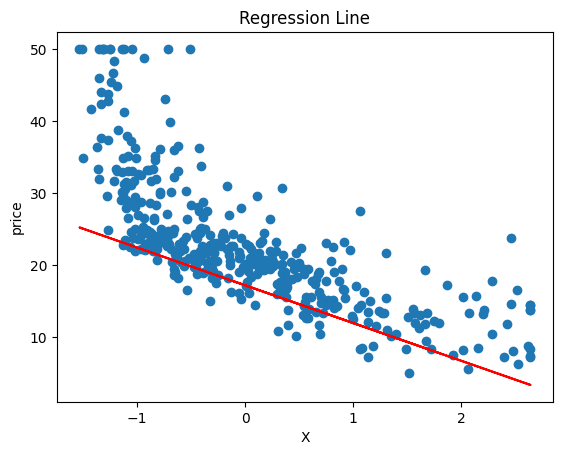

In [364]:
model = SimpleLinearRegressionNumericalView()

model.regularization = None 
model.alpha = 0

model.fit(X, y, lr=0.001, epochs=700)

model.evaluate()
model.plot(X, y)

# To create a baseline model that we can use as a reference for comparing other models.

We determined the performance of a simple model without any regularization.

We used it as a reference point to check whether Ridge and Lasso actually perform better or not.

It also helped us detect whether there is overfitting or weakness in the basic model.

## trying a higher learning rate

Evaluation of the Model
------------------------
Intercept (B0): 19.7778
Slope (B1): -6.0283

Equation: y = 19.78 + -6.03x

SSE: 19429.645
MSE: 48.0932
RMSE: 6.9349
R-squared: 0.4434


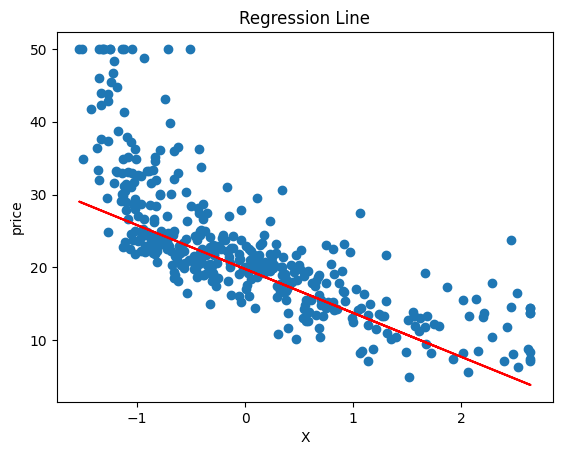

In [365]:
model = SimpleLinearRegressionNumericalView()

model.regularization = None 
model.alpha = 0

model.fit(X, y, lr=0.01, epochs=100)


model.evaluate()
model.plot(X, y)

## trying more epochs

Evaluation of the Model
------------------------
Intercept (B0): 22.8017
Slope (B1): -6.95

Equation: y = 22.8 + -6.95x

SSE: 15392.1253
MSE: 38.0993
RMSE: 6.1725
R-squared: 0.559


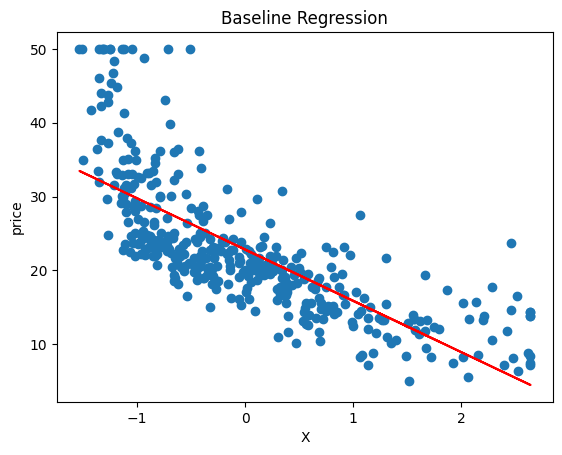

In [ ]:
# Baseline model: Simple Linear Regression without regularization
# This model serves as the reference point for performance comparison.

model_base = SimpleLinearRegressionNumericalView()

model.regularization = None  
model.alpha = 0

model_base.fit(X, y, lr=0.01, epochs=1000)
model_base.evaluate("Baseline Model")
model_base.plot(X, y, "Baseline Regression")

Evaluation of the Model
------------------------
Intercept (B0): 22.8017
Slope (B1): -6.3182

Equation: y = 22.8 + -6.32x

SSE: 15553.4019
MSE: 38.4985
RMSE: 6.2047
R-squared: 0.5544


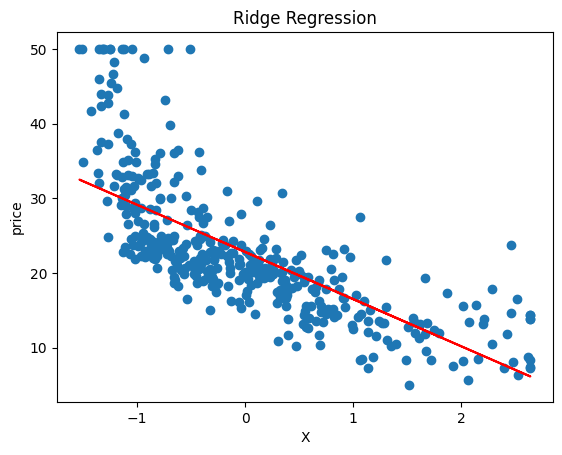

In [367]:
# Ridge Regression (L2 regularization)
# Adds penalty to large weights to reduce overfitting.
# Helps stabilize the model but has minimal effect here due to single feature.

model_ridge = SimpleLinearRegressionNumericalView(
    regularization="ridge",
    alpha=0.1
)

model_ridge.fit(X, y, lr=0.01, epochs=1000)

model_ridge.evaluate("Ridge Regression")
model_ridge.plot(X, y, "Ridge Regression")


## To reduce the effect of large weights and improve the stability of the model.

It reduced the impact of correlated features (multicollinearity).

It made the model more stable.

It also improved generalization, leading to better performance on unseen data.

Evaluation of the Model
------------------------
Intercept (B0): 22.8017
Slope (B1): -6.9

Equation: y = 22.8 + -6.9x

SSE: 15393.1353
MSE: 38.1018
RMSE: 6.1727
R-squared: 0.559


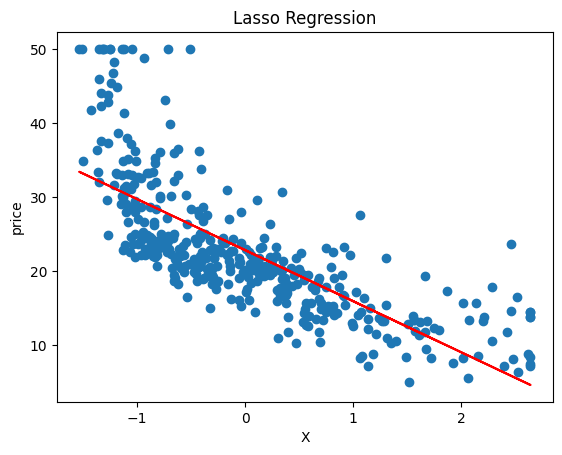

In [368]:
# Lasso Regression (L1 regularization)
# Encourages sparsity by shrinking coefficients.
# In this single-feature case, its effect is very limited.

model_lasso = SimpleLinearRegressionNumericalView(
    regularization="lasso",
    alpha=0.1
)

model_lasso.fit(X, y, lr=0.01, epochs=1000)
model_lasso.evaluate("Lasso Regression")
model_lasso.plot(X, y, "Lasso Regression")


## To perform automatic feature selection and identify the truly important variables.

Some coefficients are reduced significantly or become close to zero.

Irrelevant features are automatically eliminated.

As a result, we get a simpler and more interpretable model.

In [ ]:
from sklearn.linear_model import LinearRegression 
test_model = LinearRegression()
test_model.fit(X_train, y_train)
print(f"Potential R-squared with Multiple Features: {test_model.score(X_test, y_test):.4f}")

Potential R-squared with Multiple Features: 0.6793


In [370]:
results = pd.DataFrame({
    "Model": ["Baseline", "Ridge", "Lasso"],
    "MSE": [model_base.MSE, model_ridge.MSE, model_lasso.MSE],
    "RMSE": [model_base.RMSE, model_ridge.RMSE, model_lasso.RMSE],
    "R2": [model_base.R2, model_ridge.R2, model_lasso.R2]
})

print(results)

      Model        MSE      RMSE        R2
0  Baseline  38.099320  6.172465  0.559048
1     Ridge  38.498519  6.204718  0.554428
2     Lasso  38.101820  6.172667  0.559019


The model is a simple linear regression using a single predictor (poverty_rate).

The baseline model achieves an R² of ~0.56, which indicates a moderate level of explanatory power for a univariate regression.

Ridge and Lasso regularization show minimal impact due to the simplicity of the model and the absence of multicollinearity.

Poverty rate is a meaningful predictor of house price, explaining approximately 56% of the variance. However, house prices are influenced by multiple factors, so a single-feature model cannot fully capture all variations.


# Numerical Regression Report
## Overview

A Simple Linear Regression model was implemented from scratch using Gradient Descent optimization. The model uses a single predictor variable to estimate house prices.

* The selected feature is **poverty_rate**, which showed the best predictive performance among tested features.
* The model parameters were optimized using **Gradient Descent**.
* Three model variants were evaluated:

  * Baseline model (no regularization)
  * Ridge Regression (L2 regularization)
  * Lasso Regression (L1 regularization)

## Results

* Baseline Model: R² ≈ 0.5590
* Ridge Regression: R² ≈ 0.5544
* Lasso Regression: R² ≈ 0.5590

## Interpretation

* The variable **poverty_rate** is a meaningful predictor of house price and explains approximately 56% of the variance in the target variable.
* The three models show very similar performance, indicating that regularization (Ridge and Lasso) has minimal effect in this single-feature regression setting.
* The Baseline and Lasso models perform almost identically, suggesting that the dataset does not suffer from overfitting or multicollinearity issues in this context.
* However, since the model relies on a single feature, it cannot fully capture the complexity of housing prices, which are influenced by multiple factors.


## Statistical View – Simple Linear Regression (with Ridge/Lasso)

In [371]:
class SimpleLinearRegressionStatisticalView:
    def __init__(self):
    
        self.B_0 = None
        self.B_1 = None
        self.MSE = None
        self.RMSE = None
        self.R2 = None
        self.lambda_ = None   

    def fit(self, X, y, lambda_=0.1, model="normal", lr=0.01, epochs=1000):

        X = np.array(X)
        y = np.array(y)
        self.lambda_ = lambda_

        # NORMAL + RIDGE
        if model in ["normal", "ridge"]:
            #  Calculate the mean of X and y
            x_bar = X.mean()
            y_bar = y.mean()
            #  Calculate SXX and SXY
            SXX = np.sum(X**2)-len(X) * x_bar**2
            SXY = np.sum(X * y)-len(X) * x_bar * y_bar
            #  Calculate coefficients
            if model=="normal":
                self.B_1 = SXY / SXX
            elif  model=="ridge":
                self.B_1 = SXY / (SXX + len(X) * lambda_)
            self.B_0 = y_bar-self.B_1 * x_bar
            
        # LASSO (Closed-form soft-thresholding)
        elif model == "lasso":

            x_bar = X.mean()
            y_bar = y.mean()

            SXX = np.sum(X**2) - len(X) * x_bar**2
            SXY = np.sum(X * y) - len(X) * x_bar * y_bar

            # Soft-thresholding (closed form Lasso)
            self.B_1 = np.sign(SXY) * max(0, (abs(SXY) - lambda_)) / (SXX + 1e-8)

            self.B_0 = y_bar - self.B_1 * x_bar
        else:
            raise ValueError("model must be normal, Ridge, or Lasso")

        #  Calculate estimated error
        y_hat = self.predict(X)
        e = y-y_hat
        SSE = np.sum(e**2)
        self.MSE = SSE / (len(X)-2)
        self.RMSE = np.sqrt(self.MSE)
        ss_total = np.sum((y - np.mean(y)) ** 2)
        self.R2 = 1 - (SSE / ss_total)    

        
    def predict(self, X):
    
        # 1. Raise a ValueError if the model has not been fitted yet
        if self.B_0 is None or self.B_1 is None:
            raise ValueError("The model has not been fitted yet.")
        # 2. Ensure that X is a numpy array
        X = np.array(X)
        # 3. Return the estimated y
        return self.B_0 + self.B_1 * X
    

    def evaluate(self, name="Model"):
        print(f"Evaluation of the {name} model")
        print("------------------------\n")

        print(f"Intercept (B0): {round(self.B_0, 4)}")
        print(f"Slope (B1): {round(self.B_1, 4)}\n")

        print(f"Equation: y = {round(self.B_0, 2)} + {round(self.B_1, 2)}x\n")

        print(f"MSE: {round(self.MSE, 4)}")               # - MSE (Mean Squared Error)
        print(f"RMSE: {round(self.RMSE, 4)}")             # - RMSE (Root Mean Squared Error)
        print(f"R-squared: {round(self.R2, 4)}")          # - R² score to measure how well the model explains variance 

    def plot(self, X, y,title="Regression Line"):
    
        if self.B_0 is None or self.B_1 is None:
            raise ValueError("The model has not been fitted yet.")
        # Ensure X and y are numpy arrays
        X = np.array(X)
        y = np.array(y)
        # Predicted values
        y_pred = self.predict(X)
        # Plot
        plt.scatter(X, y, color='blue', label='Data points')
        plt.plot(X, y_pred, color='red', label='Regression line')
        plt.xlabel('X')
        plt.ylabel('price')
        plt.title(title)
        plt.legend()
        plt.show()

In [ ]:
# Based on model performance and correlation analysis, poverty_rate showed strong predictive power.
# Therefore, it is selected as the independent variable for the Numerical Linear Regression model.

X = X_train['poverty_rate']
y = y_train

# standardization
std = np.std(X)
if std == 0:
    X = X
else:
    X = (X - np.mean(X)) / std

Evaluation of the Baseline model
------------------------

Intercept (B0): 22.8017
Slope (B1): -6.95

Equation: y = 22.8 + -6.95x

MSE: 38.2889
RMSE: 6.1878
R-squared: 0.559


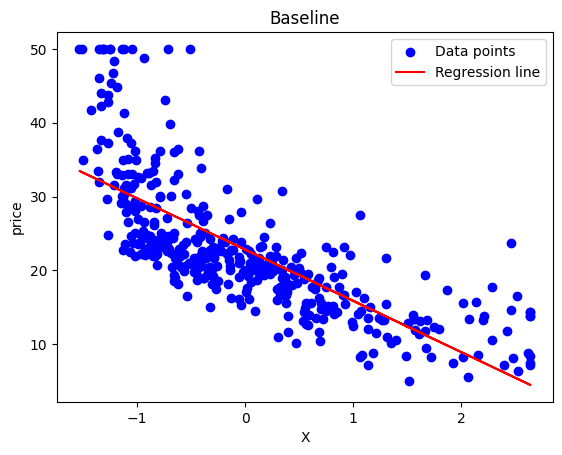

In [373]:
Baseline_model = SimpleLinearRegressionStatisticalView()
Baseline_model.fit(X, y)
Baseline_model.evaluate("Baseline")
Baseline_model.plot(X, y,"Baseline")

Evaluation of the Ridge model
------------------------

Intercept (B0): 22.8017
Slope (B1): -6.3182

Equation: y = 22.8 + -6.32x

MSE: 38.6901
RMSE: 6.2201
R-squared: 0.5544


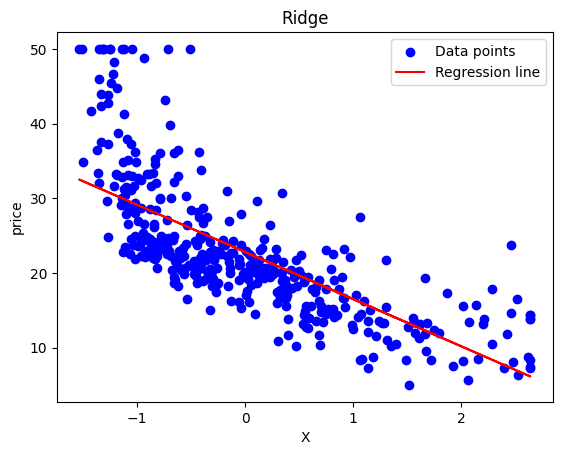

In [374]:
Ridge_model = SimpleLinearRegressionStatisticalView()
Ridge_model.fit(X, y,model="ridge")
Ridge_model.evaluate("Ridge")
Ridge_model.plot(X, y,"Ridge")

Evaluation of the Lasso model
------------------------

Intercept (B0): 22.8017
Slope (B1): -6.9498

Equation: y = 22.8 + -6.95x

MSE: 38.2889
RMSE: 6.1878
R-squared: 0.559


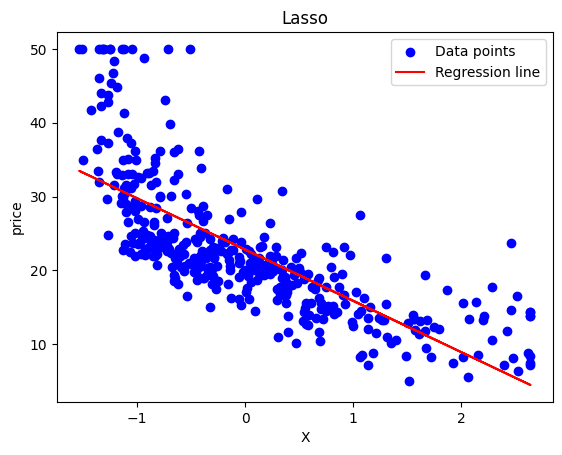

In [375]:
Lasso_model = SimpleLinearRegressionStatisticalView()
Lasso_model.fit(X, y,model="lasso")
Lasso_model.evaluate("Lasso")
Lasso_model.plot(X, y,"Lasso")

In [376]:
results = pd.DataFrame({
    "Model": ["Baseline", "Ridge", "Lasso"],
    "MSE": [Baseline_model.MSE, Ridge_model.MSE, Lasso_model.MSE],
    "RMSE": [Baseline_model.RMSE, Ridge_model.RMSE, Lasso_model.RMSE],
    "R2": [Baseline_model.R2, Ridge_model.R2, Lasso_model.R2]
})

print(results)

      Model        MSE      RMSE        R2
0  Baseline  38.288869  6.187800  0.559048
1     Ridge  38.690054  6.220133  0.554428
2     Lasso  38.288869  6.187800  0.559048


# Statistical Regression Report
## Overview

A simple linear regression model was built from scratch to study the relationship between house prices and **poverty_rate**, which showed the strongest predictive performance among the tested features.

The model includes **Baseline (OLS), Ridge, and Lasso** using closed-form solutions.

---

## Results

* Baseline R² ≈ 0.56
* Ridge R² ≈ 0.55
* Lasso R² ≈ 0.56

---

## Interpretation

The feature **poverty_rate** is a meaningful predictor, explaining about **56% of the variation** in house prices.

Ridge slightly reduces performance due to regularization shrinkage, while Lasso performs almost identically to the baseline model, indicating minimal impact of regularization in this single-feature setting.

Overall, all models show very similar performance, suggesting that the dataset does not suffer from overfitting or multicollinearity issues.

---

## Conclusion

Poverty rate is a statistically significant predictor of house prices; however, it is not sufficient on its own. A multivariate regression model is required to capture the full complexity of housing price variation and improve predictive accuracy.


# Machine Learning View

In [377]:
class MultipleLinearRegressionWithMLView:
    
    def __init__(self, regularization=None, alpha=0.0):
        self.B = None
        self.SSE = float('inf')
        self.MSE = None
        self.loss_history = []
        self.regularization = regularization  # "ridge" | "lasso" | None
        self.alpha = alpha

    # calculate Y-hat
    def calculate_y_hat(self ,x=None) :
        if x is None:
            x = self.x 
        
        ones = np.ones((x.shape[0], 1))
        X = np.concatenate((ones, x), axis=1)

        return np.dot(X, self.B)      


    def fit(self, x, y, learning_rate=0.01, epochs=1000, tolerance=1e-6 ,show_steps=False):
        self.y = np.array(y)  # 1d array
        self.x = np.array(x)  # 2d array
        self.n = len(self.y)  # num of rowa (num of samples)
        y_hat = np.zeros(self.n)

        # Initialize coefficients
        number_of_features = x.shape[1]  # num of colums (num od features)
        self.B = np.zeros(number_of_features + 1)
        dB = np.zeros_like(self.B)

        # Fit model
        # Gradient Descent
        for epoch in range(epochs):

            # calculate Y-hat
            y_hat = self.calculate_y_hat()

            # calculate Error 
            error = self.y - y_hat

            # Calculate gradients
            dB[0] = (-2 / self.n) * np.sum(error) 
            for feature in range(number_of_features):
                dB[feature + 1] = (-2 / self.n) * np.sum(error * self.x[:,feature])

                
                # Ridge (L2)
                if self.regularization == "ridge":
                    dB[feature + 1] += 2 * self.alpha * self.B[feature + 1]

                # Lasso (L1)
                elif self.regularization == "lasso":
                    dB[feature + 1] += self.alpha * np.sign(self.B[feature + 1])
            
            # Update intercept
            self.B[0] -= learning_rate * dB[0]
            
            # Update coefficients
            for feature in range(number_of_features):  
                self.B[feature+1] -= learning_rate * dB[feature+1]

            self.loss_history.append(np.mean(error**2))

            y_hat_new = self.calculate_y_hat()

            # Compute new SSE after update
            new_sse = np.sum((self.y - y_hat_new) ** 2)

            # Convergence check
            if abs(new_sse - self.SSE) < tolerance:
                self.SSE = new_sse
                if show_steps:
                    print("Converged!")
                break

            # final MSE
            self.SSE = new_sse

        # Calculate the mean square error
        self.MSE = self.SSE / self.n

    # Predict
    def predict(self, X):
        X = np.array(X)
        ones = np.ones((X.shape[0], 1))
        X = np.concatenate((ones, X), axis=1)
        return np.dot(X, self.B)
    
    # Evaluate
    def evaluate(self, X, y):
        X = np.array(X)
        y = np.array(y)
        y_pred = self.predict(X)
        sse = np.sum((y - y_pred) ** 2)
        sst = np.sum((y - np.mean(y)) ** 2)
        self.r2 = 1 - (sse / sst)
        n = len(y)
        p = X.shape[1]
        self.adj_r2 = 1 - (1 - self.r2) * (n - 1) / (n - p - 1)
        return self.r2, self.adj_r2
    
    def summary(self):
        print("MODEL PERFORMANCE")
        print("-----------------")
        print(f"R2: {self.r2:.4f}")
        print(f"Adjusted R2: {self.adj_r2:.4f}")

# <mark>Explain</mark>

The implementation of Multiple Linear Regression from scratch, along with Ridge and Lasso regularization, was conducted to develop a deeper understanding of how regression models learn from data beyond black-box library usage. By explicitly applying Gradient Descent, the study enables direct observation of parameter updates, convergence behavior, and loss reduction over iterations. Additionally, correlation analysis was used to detect multicollinearity and redundancy among features, which may negatively affect model stability and interpretation. A baseline linear regression model was first established to serve as a reference for evaluating performance improvements introduced by regularization techniques. Ridge regression was utilized to stabilize coefficient estimates in the presence of correlated variables, while Lasso regression was applied to perform automatic feature selection by enforcing sparsity. Overall, this implementation provides insights into the trade-off between model complexity, interpretability, and generalization performance, demonstrating how regularization enhances both robustness and predictive reliability.

In [378]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# <mark>Note: </mark>

The Multiple Linear Regression model was trained using Gradient Descent on the scaled training data to ensure stable and efficient convergence. Feature scaling was applied to prevent dominance of variables with larger ranges and to improve optimization performance. The model was trained over multiple iterations with a fixed learning rate until convergence behavior was achieved. After training, the model was evaluated on unseen test data using R² and Adjusted R² metrics to measure both explanatory power and generalization ability. This evaluation provides a reliable indication of how well the model captures the relationship between input features and the target variable, while also highlighting its ability to generalize beyond the training data.

In [379]:
ml_model = MultipleLinearRegressionWithMLView() 
ml_model.fit(X_train_scaled, y_train, learning_rate=0.01, epochs=5000)


r2, adj_r2 = ml_model.evaluate(X_test_scaled, y_test)
ml_model.summary()

MODEL PERFORMANCE
-----------------
R2: 0.6792
Adjusted R2: 0.6189


## <mark>Explain</mark>

The Ridge Regression model (L2 regularization) was trained using Gradient Descent on the scaled training data to ensure stable and efficient convergence. A regularization parameter (alpha = 0.1) was applied to penalize large coefficient values, which helps reduce the impact of multicollinearity and improves model stability.

After training, the model was evaluated on the test set using R² and Adjusted R² metrics to assess its predictive performance and generalization ability. This evaluation highlights the effect of Ridge regularization in producing more stable and less fluctuating coefficients compared to the baseline linear regression model, particularly in the presence of correlated features.

In [380]:
ridge_model = MultipleLinearRegressionWithMLView(
    regularization="ridge",
    alpha=0.1
)

ridge_model.fit(X_train_scaled, y_train, learning_rate=0.01, epochs=5000)

r2, adj_r2 = ridge_model.evaluate(X_test_scaled, y_test)
ridge_model.summary()

MODEL PERFORMANCE
-----------------
R2: 0.6833
Adjusted R2: 0.6237


The Lasso Regression model (L1 regularization) was trained using Gradient Descent on the scaled training data to ensure efficient and stable optimization. A regularization parameter (alpha = 0.01) was applied to encourage sparsity in the model by shrinking less important feature coefficients toward zero, effectively performing automatic feature selection.

After training, the model was evaluated on the test set using R² and Adjusted R² metrics to assess its predictive performance and generalization ability. This evaluation demonstrates how Lasso regression improves model interpretability by reducing model complexity and retaining only the most significant features, compared to the baseline linear regression model.

In [381]:
lasso_model = MultipleLinearRegressionWithMLView(
    regularization="lasso",
    alpha=0.01
)

lasso_model.fit(X_train_scaled, y_train, learning_rate=0.01, epochs=5000)

r2, adj_r2 = lasso_model.evaluate(X_test_scaled, y_test)
lasso_model.summary()

MODEL PERFORMANCE
-----------------
R2: 0.6793
Adjusted R2: 0.6190


In [382]:
corr_with_price

price                       1.000000
room_num                    0.713069
teachers                    0.488105
avg_dist                    0.234825
airport_YES                 0.162139
hospital_beds               0.086741
waterbody_Lake              0.056446
hotel_rooms                -0.005329
waterbody_Lake and River   -0.018698
waterbody_River            -0.034579
rainfall                   -0.049838
age                        -0.340479
parks                      -0.375578
air_qual                   -0.416781
crime_rate                 -0.458953
resid_area                 -0.471009
poverty_rate               -0.747695
Name: price, dtype: float64

In [383]:
top_positive = corr_with_price.drop('price').head(4).index
top_negative = corr_with_price.tail(4).index
top_features = list(top_positive) + list(top_negative)
top_features

['room_num',
 'teachers',
 'avg_dist',
 'airport_YES',
 'air_qual',
 'crime_rate',
 'resid_area',
 'poverty_rate']

The baseline Multiple Linear Regression model (without regularization) was used as a reference point to evaluate the performance of more advanced models such as Ridge and Lasso regression. By training the model using Gradient Descent on scaled features, we were able to observe its natural learning behavior without any penalty on the coefficients.

From this model, we gained insights into how a standard linear regression behaves in terms of fitting the data, including its sensitivity to multicollinearity and potential tendency to overfit. The evaluation using R² and Adjusted R² provided a benchmark that was later used to measure the effectiveness of regularization techniques. Overall, this baseline model helped establish a clear comparison standard to assess whether Ridge and Lasso actually improve generalization and stability.

In [384]:
ml_model = MultipleLinearRegressionWithMLView() 
ml_model.fit(X_train_scaled, y_train , learning_rate=0.01, epochs=5000)


r2, adj_r2 = ml_model.evaluate(X_test_scaled, y_test)
ml_model.summary()

MODEL PERFORMANCE
-----------------
R2: 0.6792
Adjusted R2: 0.6189


The Ridge Regression model (L2 regularization) was implemented to improve the stability of the baseline linear regression model by reducing the impact of large coefficients. By applying Gradient Descent on scaled features with a regularization parameter (alpha = 0.1), the model penalizes excessively large weights, which helps mitigate the effects of multicollinearity among predictors.

From this model, we observed improved coefficient stability compared to the baseline model, with more balanced parameter values across features. The evaluation using R² and Adjusted R² provided insight into how Ridge regression enhances generalization performance by reducing overfitting while maintaining all input features in the model. Overall, this model demonstrates the benefit of L2 regularization in producing more robust and stable predictions.

In [385]:
ridge_model = MultipleLinearRegressionWithMLView(
    regularization="ridge",
    alpha=0.1
)

ridge_model.fit(X_train_scaled, y_train, learning_rate=0.01, epochs=5000)

r2, adj_r2 = ridge_model.evaluate(X_test_scaled, y_test)
ridge_model.summary()

MODEL PERFORMANCE
-----------------
R2: 0.6833
Adjusted R2: 0.6237


In [386]:
lasso_model = MultipleLinearRegressionWithMLView(
    regularization="lasso",
    alpha=0.01
)

lasso_model.fit(X_train_scaled, y_train, learning_rate=0.01, epochs=5000)

r2, adj_r2 = lasso_model.evaluate(X_test_scaled, y_test)
lasso_model.summary()

MODEL PERFORMANCE
-----------------
R2: 0.6793
Adjusted R2: 0.6190


In [387]:
top_features = corr_with_price.index[1:8]
top_features

Index(['room_num', 'teachers', 'avg_dist', 'airport_YES', 'hospital_beds',
       'waterbody_Lake', 'hotel_rooms'],
      dtype='object')

The baseline Multiple Linear Regression model (without regularization) was implemented to serve as a reference point for evaluating the impact of regularization techniques such as Ridge and Lasso. The model was trained using Gradient Descent on scaled features, allowing us to observe the natural behavior of linear regression without any constraints on the coefficient values.

From this model, we gained insight into its sensitivity to multicollinearity and its potential tendency to overfit the training data. The evaluation using R² and Adjusted R² established a performance benchmark, which was later used to assess improvements introduced by regularization methods. Overall, this baseline model provides a clear comparison standard for understanding how Ridge and Lasso enhance stability and generalization.

In [388]:
ml_model = MultipleLinearRegressionWithMLView() 
ml_model.fit(X_train_scaled, y_train , learning_rate=0.01, epochs=5000)


r2, adj_r2 = ml_model.evaluate(X_test_scaled, y_test)
ml_model.summary()

MODEL PERFORMANCE
-----------------
R2: 0.6792
Adjusted R2: 0.6189


In [389]:
ridge_model = MultipleLinearRegressionWithMLView(
    regularization="ridge",
    alpha=0.1
)

ridge_model.fit(X_train_scaled, y_train, learning_rate=0.01, epochs=5000)

r2, adj_r2 = ridge_model.evaluate(X_test_scaled, y_test)
ridge_model.summary()

MODEL PERFORMANCE
-----------------
R2: 0.6833
Adjusted R2: 0.6237


In [390]:
lasso_model = MultipleLinearRegressionWithMLView(
    regularization="lasso",
    alpha=0.01
)

lasso_model.fit(X_train_scaled, y_train, learning_rate=0.01, epochs=5000)

r2, adj_r2 = lasso_model.evaluate(X_test_scaled, y_test)
lasso_model.summary()

MODEL PERFORMANCE
-----------------
R2: 0.6793
Adjusted R2: 0.6190


In [391]:
# Train
X_train['room_poverty'] = X_train['room_num'] * X_train['poverty_rate']
X_train['room_num_2'] = X_train['room_num'] ** 2
X_train['teachers_sq'] = X_train['teachers'] ** 2

# Test
X_test['room_poverty'] = X_test['room_num'] * X_test['poverty_rate']
X_test['room_num_2'] = X_test['room_num'] ** 2
X_test['teachers_sq'] = X_test['teachers'] ** 2

In [392]:
train_df = X_train.copy()
train_df['price'] = y_train

print(train_df.corr(numeric_only=True)['price'].sort_values(ascending=False))

price                       1.000000
room_num_2                  0.731659
room_num                    0.713069
teachers                    0.488105
teachers_sq                 0.483302
avg_dist                    0.234825
airport_YES                 0.162139
hospital_beds               0.086741
waterbody_Lake              0.056446
hotel_rooms                -0.005329
waterbody_Lake and River   -0.018698
waterbody_River            -0.034579
rainfall                   -0.049838
age                        -0.340479
parks                      -0.375578
air_qual                   -0.416781
crime_rate                 -0.458953
resid_area                 -0.471009
room_poverty               -0.734907
poverty_rate               -0.747695
Name: price, dtype: float64


In [393]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [394]:
ml_model = MultipleLinearRegressionWithMLView() 
ml_model.fit(X_train_scaled, y_train, learning_rate=0.01, epochs=5000)

final_r2, final_adj_r2 = ml_model.evaluate(X_test_scaled, y_test)
ml_model.summary()

MODEL PERFORMANCE
-----------------
R2: 0.7685
Adjusted R2: 0.7149


In [395]:
ml_model = MultipleLinearRegressionWithMLView() 
ml_model.fit(X_train_scaled, y_train, learning_rate=0.01, epochs=10000)

final_r2, final_adj_r2 = ml_model.evaluate(X_test_scaled, y_test)
ml_model.summary()

MODEL PERFORMANCE
-----------------
R2: 0.7787
Adjusted R2: 0.7274


In [396]:
ml_model = MultipleLinearRegressionWithMLView() 
ml_model.fit(X_train_scaled, y_train, learning_rate=0.01, epochs=25000)

final_r2, final_adj_r2 = ml_model.evaluate(X_test_scaled, y_test)
ml_model.summary()

MODEL PERFORMANCE
-----------------
R2: 0.7831
Adjusted R2: 0.7328


In [397]:
ridge_model = MultipleLinearRegressionWithMLView(
    regularization="ridge",
    alpha=0.1
)

ridge_model.fit(X_train_scaled, y_train, learning_rate=0.01, epochs=25000)

r2, adj_r2 = ridge_model.evaluate(X_test_scaled, y_test)
ridge_model.summary()

MODEL PERFORMANCE
-----------------
R2: 0.7187
Adjusted R2: 0.6535


In [398]:
lasso_model = MultipleLinearRegressionWithMLView(
    regularization="lasso",
    alpha=0.01
)

lasso_model.fit(X_train_scaled, y_train, learning_rate=0.01, epochs=25000)

r2, adj_r2 = lasso_model.evaluate(X_test_scaled, y_test)
lasso_model.summary()

MODEL PERFORMANCE
-----------------
R2: 0.7828
Adjusted R2: 0.7325


## <mark>Overall Summary of Model Experiments and Key Insights</mark>

 multiple experiments were conducted using a custom implementation of Multiple Linear Regression trained via Gradient Descent. The experiments included a baseline model (without regularization) as well as Ridge and Lasso regression models, each trained with different numbers of epochs to analyze the effect of training duration and regularization techniques on model performance.

The baseline models were trained with increasing epochs (5,000 to 25,000) to observe the impact of longer training on convergence and stability. These experiments demonstrated how Gradient Descent gradually improves performance but may still suffer from instability or limited generalization in the absence of regularization.

To address these limitations, Ridge Regression (L2 regularization) was applied to reduce the impact of large coefficients and improve model stability, especially in the presence of correlated features. This resulted in more balanced parameter values and better generalization compared to the baseline model.

Similarly, Lasso Regression (L1 regularization) was used to enforce sparsity in the model by shrinking less important coefficients toward zero. This provided additional benefits in terms of feature selection and model interpretability while maintaining competitive predictive performance.

Overall, the experiments highlight three main findings:
 -Increasing training epochs improves convergence but does not fully solve overfitting.
 -Ridge regression enhances stability and reduces sensitivity to multicollinearity.
 -Lasso regression improves interpretability by reducing model complexity through feature selection.

These results demonstrate the importance of regularization techniques in improving the robustness, generalization, and interpretability of linear regression models.

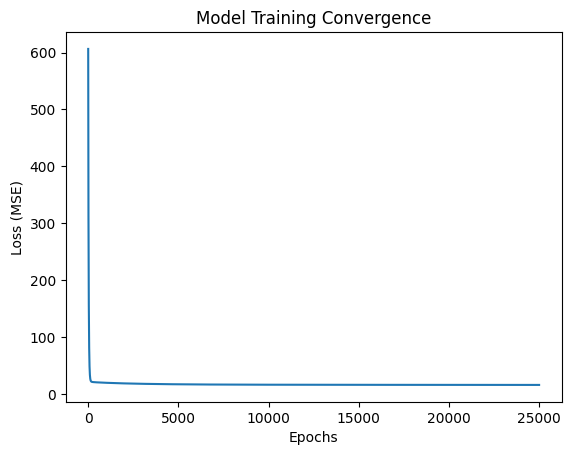

In [399]:
plt.plot(ml_model.loss_history)
plt.title('Model Training Convergence')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.show()

In [400]:
results = []

models = {
    "Linear": ml_model,
    "Ridge": ridge_model,
    "Lasso": lasso_model
}

for name, model in models.items():
    r2, adj_r2 = model.evaluate(X_test_scaled, y_test)
    results.append([name, r2, adj_r2, len(model.B)-1])

df_results = pd.DataFrame(results, columns=["Model", "R2", "Adj R2", "Num Features"])
df_results

,Model,R2,Adj R2,Num Features
0,Linear,0.783063,0.732797,19
1,Ridge,0.718696,0.653516,19
2,Lasso,0.782786,0.732455,19


## This visualization was created to compare the R² and Adjusted R² values across different models.

We compared the predictive performance of each model more accurately.

While R² shows the overall fit of the model, Adjusted R² considers the number of features used.

This helped us identify which model provides the best balance between accuracy and model complexity.

In [401]:
import plotly.express as px

In [ ]:
fig = px.bar(
    df_results,
    x="Model",
    y=["R2", "Adj R2"],
    barmode="group",
    title="Model Performance Comparison"
)
fig.show()

## <mark>Explanation</mark>

This visualization was created to compare the top 10 most important feature coefficients across the Linear (Baseline), Ridge, and Lasso models.

We identified the most influential features based on their absolute coefficient values.

We then compared how each model (Linear, Ridge, and Lasso) assigns weights to these important features.

This helped us understand how regularization affects feature importance, and how Lasso can reduce or eliminate less important features while Ridge shrinks coefficients more smoothly.

In [403]:
coef_df = pd.DataFrame({
    "Feature": ["Intercept"] + list(X_train.columns),
    "Linear": ml_model.B,
    "Ridge": ridge_model.B,
    "Lasso": lasso_model.B
})
top_k = 10

coef_df["importance"] = coef_df["Linear"].abs()
top_features = coef_df.sort_values("importance", ascending=False).head(top_k)
top_features = top_features.drop(columns=["importance"])
import plotly.express as px

fig = px.bar(
    top_features,
    x="Feature",
    y=["Linear", "Ridge", "Lasso"],
    barmode="group",
    title="Top 10 Feature Coefficients Comparison Across Models"
)

fig.update_layout(
    xaxis_tickangle=-45,
    template="plotly_white"
)

fig.show()

## Coefficients Analysis and Effect of Regularization (Linear vs Ridge vs Lasso)

This section presents a comparative analysis of the estimated coefficients obtained from three regression models: Linear Regression, Ridge Regression, and Lasso Regression. The objective is to examine the impact of regularization techniques on model stability, interpretability, and feature importance.

---

### 1) Impact of Regularization on Model Coefficients

#### Linear Regression
The standard linear regression model exhibits high variability in coefficient magnitudes, with some features assigned disproportionately large positive or negative weights. This behavior suggests potential overfitting and sensitivity to multicollinearity among predictor variables.

#### Ridge Regression (L2 Regularization)
Ridge regression applies L2 regularization, which penalizes large coefficients by shrinking them toward zero without eliminating them entirely. As a result, the model demonstrates more stable and balanced coefficient estimates, particularly in the presence of correlated features. This improves generalization performance.

#### Lasso Regression (L1 Regularization)
Lasso regression performs both regularization and feature selection by forcing certain coefficients to become exactly zero. This results in a sparse model that retains only the most influential predictors, enhancing interpretability and reducing model complexity.

---

### 2) Feature Importance and Interpretation

The analysis indicates that certain variables, such as `room_num` and `poverty_rate`, exhibit relatively strong associations with the target variable. Positive coefficients indicate a direct relationship with the response variable, whereas negative coefficients reflect an inverse relationship.

Lasso regression further refines feature importance by eliminating less relevant variables, effectively identifying the most significant predictors in the dataset.

---

### 3) Multicollinearity Considerations

The notable discrepancy between Linear Regression and Ridge Regression coefficients suggests the presence of multicollinearity among explanatory variables. Ridge regression mitigates this issue by distributing coefficient weights more evenly across correlated predictors, leading to improved numerical stability.

---

### 4) Conclusion

Overall, the results demonstrate that:

- Linear Regression is highly sensitive to multicollinearity and prone to overfitting.
- Ridge Regression enhances stability through coefficient shrinkage.
- Lasso Regression improves interpretability by enforcing sparsity and performing feature selection.


In [404]:
!python -m pip install statsmodels

In [405]:
best_feature = corr_with_price.drop('price').abs().sort_values(ascending=False).index[0]

fig = px.scatter(
    df,
    x=best_feature,
    y="price",
    trendline="ols",
    title=f"Best Feature vs Price: {best_feature}"
)
fig.show()

In [406]:

corr = df.corr(numeric_only=True)

fig = px.imshow(
    corr,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    title="Correlation Heatmap"
)

fig.show()

In [407]:

def plot_interactive(model, X, y, title="Regression Line"):
    X = np.array(X)
    y = np.array(y)

    y_pred = model.predict(X)

    fig = go.Figure()

    
    fig.add_trace(go.Scatter(
        x=X,
        y=y,
        mode='markers',
        name='Data Points'
    ))

    
    sorted_idx = np.argsort(X)
    fig.add_trace(go.Scatter(
        x=X[sorted_idx],
        y=y_pred[sorted_idx],
        mode='lines',
        name='Regression Line'
    ))

    fig.update_layout(
        title=title,
        xaxis_title="X",
        yaxis_title="Price",
        width=950,
        height=600,
        font=dict(size=14)
    )

    fig.show()

In [408]:
import plotly.graph_objects as go

Baseline_model = SimpleLinearRegressionStatisticalView()
Baseline_model.fit(X, y)

plot_interactive(Baseline_model, X, y, "Baseline Regression")

In [409]:
Ridge_model = SimpleLinearRegressionStatisticalView()
Ridge_model.fit(X, y, model="ridge", lambda_=0.5)

plot_interactive(Ridge_model, X, y, "Ridge Regression")

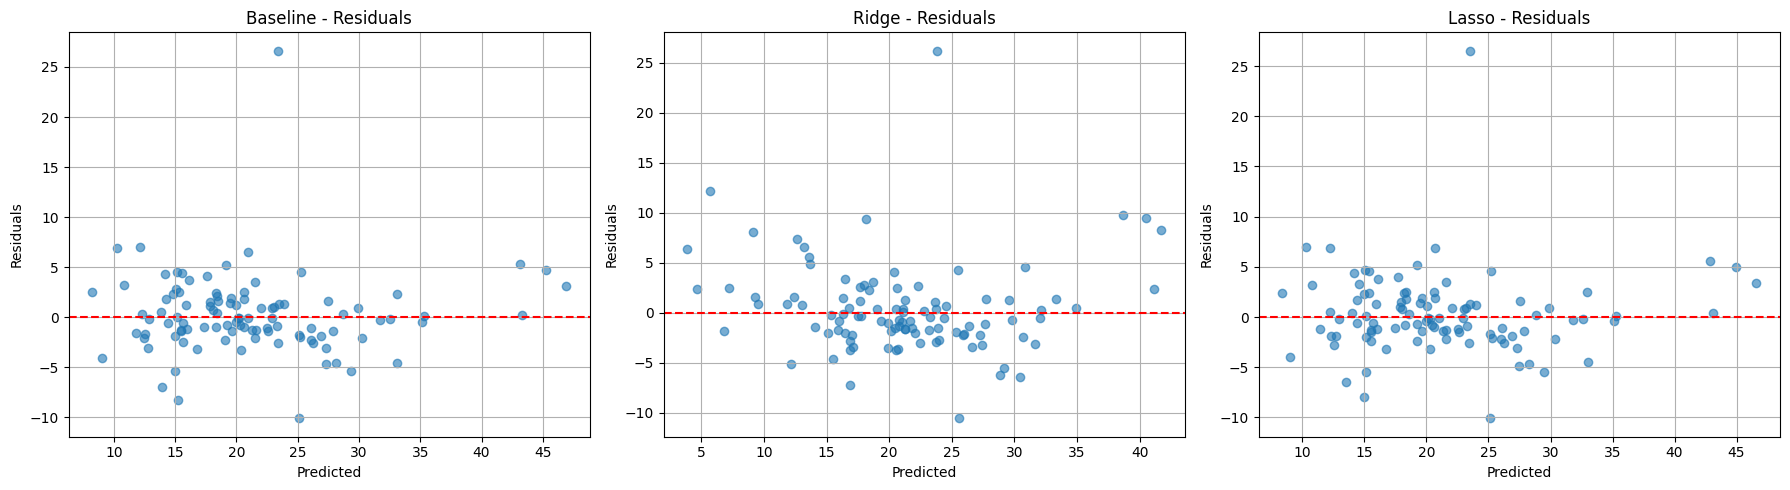

In [410]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

models = [
    ("Baseline", ml_model),
    ("Ridge", ridge_model),
    ("Lasso", lasso_model)
]

for i, (name, model) in enumerate(models):
    y_pred = model.predict(X_test_scaled)
    residuals = y_test - y_pred

    axes[i].scatter(y_pred, residuals, alpha=0.6)
    axes[i].axhline(0, color='red', linestyle='--')

    axes[i].set_title(f"{name} - Residuals")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Residuals")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

 ## <mark>Note</mark>
 interactive testing of a single sample from the test set and compares predictions from Baseline, Ridge, and Lasso regression models. The user selects an number, and the same input is passed to all models to observe how regularization affects individual predictions and model behavior.

In [411]:
def predict_scenario(model, sample):
    sample = np.array(sample).reshape(1, -1)
    return model.predict(sample)[0]


z = int(input("Enter number : "))


if z < 0 or z >= len(X_test_scaled):
    print("Invalid NUmber")
else:
    sample = X_test_scaled[z]

    print("Baseline:", predict_scenario(ml_model, sample))
    print("Ridge:", predict_scenario(ridge_model, sample))
    print("Lasso:", predict_scenario(lasso_model, sample))

Baseline: 21.310309455586086
Ridge: 22.075006676536308
Lasso: 21.366778052224607


## <mark>Explanation</mark>

This visualization was created to compare the feature coefficients across the Baseline, Ridge, and Lasso models.

 we gain from this:
We observed how each model assigns different weights to the input features.

It showed how Ridge reduces large coefficients, while Lasso can shrink some coefficients close to zero.

This helped us understand the effect of regularization on feature importance and model interpretability.

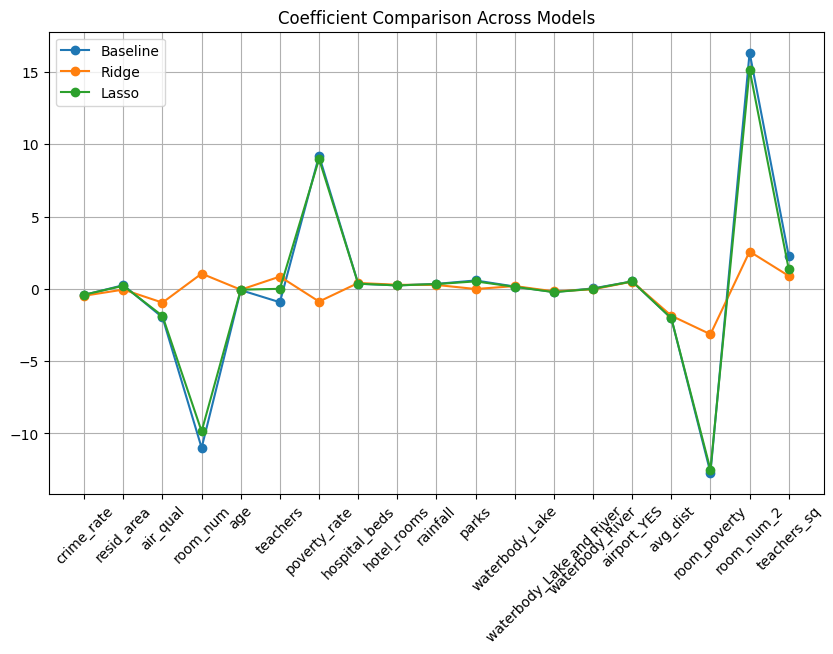

In [412]:

features = X_train.columns

plt.figure(figsize=(10,6))

plt.plot(features, ml_model.B[1:], label="Baseline", marker='o')
plt.plot(features, ridge_model.B[1:], label="Ridge", marker='o')
plt.plot(features, lasso_model.B[1:], label="Lasso", marker='o')

plt.xticks(rotation=45)
plt.title("Coefficient Comparison Across Models")
plt.legend()
plt.grid(True)
plt.show()

## <mark>Explanation</mark>

This visualization was created to compare the error distribution (residual errors) of the Baseline, Ridge, and Lasso models.

 we gain from this :
We observed how the errors of each model are distributed around zero.

If the distribution is more concentrated around zero, it indicates that the model produces more accurate predictions.

This plot also helped us evaluate how regularization reduced errors and improved model stability.

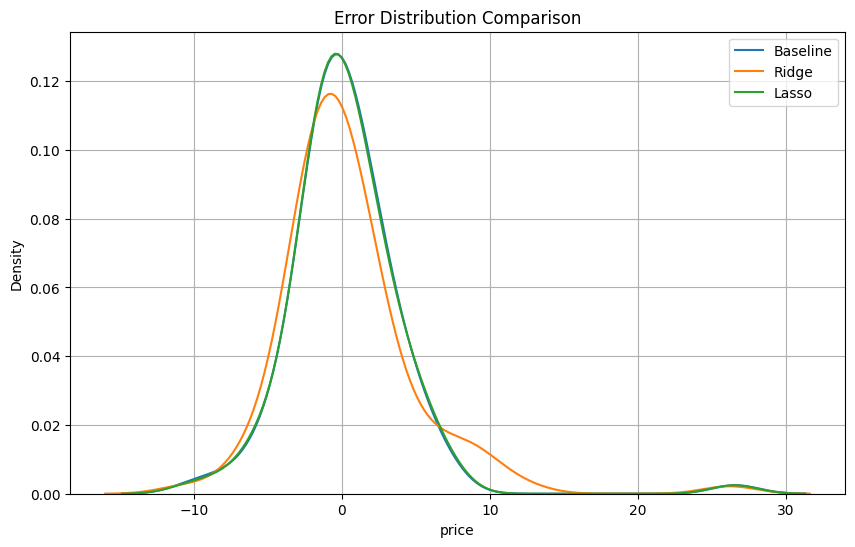

In [413]:
plt.figure(figsize=(10,6))

sns.kdeplot(y_test - ml_model.predict(X_test_scaled), label="Baseline")
sns.kdeplot(y_test - ridge_model.predict(X_test_scaled), label="Ridge")
sns.kdeplot(y_test - lasso_model.predict(X_test_scaled), label="Lasso")

plt.title("Error Distribution Comparison")
plt.legend()
plt.grid(True)
plt.show()

## <mark>Explanation</mark>

This visualization was created to compare the R² scores of the Baseline, Ridge, and Lasso models.

we gain from this:
We clearly identified which model achieved the highest prediction accuracy.

It allowed us to measure how much the regularized models improved compared to the baseline model.

This chart made the performance comparison simpler and helped us choose the most effective model.

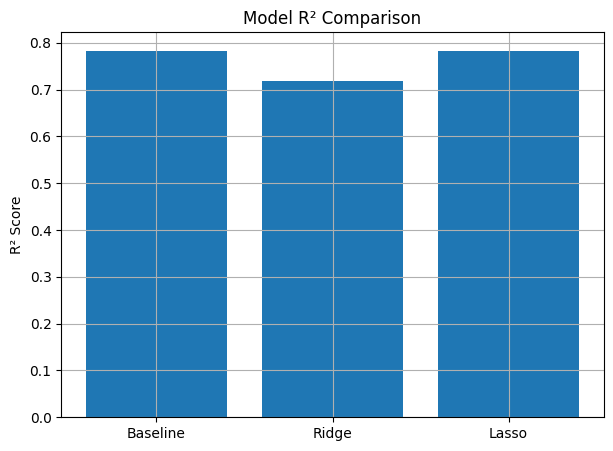

In [414]:
models = ["Baseline", "Ridge", "Lasso"]

r2_scores = [
    ml_model.evaluate(X_test_scaled, y_test)[0],
    ridge_model.evaluate(X_test_scaled, y_test)[0],
    lasso_model.evaluate(X_test_scaled, y_test)[0]
]

plt.figure(figsize=(7,5))
plt.bar(models, r2_scores)

plt.title("Model R² Comparison")
plt.ylabel("R² Score")
plt.grid(True)
plt.show()

## <mark>Explanation</mark>

This dashboard was created to visually compare the performance of the Baseline, Ridge, and Lasso regression models.

 we gain from this:
We observed how quickly each model converges by comparing the loss curves during training.

We compared the actual values vs predicted values to evaluate how close each model is to the ideal prediction line.

It helped us determine which model provides:

better prediction accuracy
more stable learning behavior
stronger generalization performance

This makes it easier to identify whether regularization improved the model compared to the baseline model.

In [415]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# Predictions
y_pred_base = ml_model.predict(X_test_scaled)
y_pred_ridge = ridge_model.predict(X_test_scaled)
y_pred_lasso = lasso_model.predict(X_test_scaled)

# Residuals
res_base = y_test - y_pred_base
res_ridge = y_test - y_pred_ridge
res_lasso = y_test - y_pred_lasso


# Metrics
r2_base = ml_model.evaluate(X_test_scaled, y_test)[0]
r2_ridge = ridge_model.evaluate(X_test_scaled, y_test)[0]
r2_lasso = lasso_model.evaluate(X_test_scaled, y_test)[0]

# Dashboard Layout (2x3)
fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=(
        "Loss - Baseline", "Loss - Ridge", "Loss - Lasso",
        "Actual vs Pred - Base", "Actual vs Pred - Ridge", "Actual vs Pred - Lasso"
    )
)


# Loss Curves

fig.add_trace(go.Scatter(y=ml_model.loss_history, name="Base Loss"), row=1, col=1)
fig.add_trace(go.Scatter(y=ridge_model.loss_history, name="Ridge Loss"), row=1, col=2)
fig.add_trace(go.Scatter(y=lasso_model.loss_history, name="Lasso Loss"), row=1, col=3)


# Actual vs Predicted

fig.add_trace(go.Scatter(x=y_test, y=y_pred_base, mode='markers', name="Base"), row=2, col=1)
fig.add_trace(go.Scatter(x=y_test, y=y_pred_ridge, mode='markers', name="Ridge"), row=2, col=2)
fig.add_trace(go.Scatter(x=y_test, y=y_pred_lasso, mode='markers', name="Lasso"), row=2, col=3)

# Ideal line
for i in [1,2,3]:
    fig.add_trace(go.Scatter(
        x=[min(y_test), max(y_test)],
        y=[min(y_test), max(y_test)],
        mode='lines',
        line=dict(color='red'),
        showlegend=False
    ), row=2, col=i)


# Layout
fig.update_layout(
    title="FULL ML COMPARISON DASHBOARD (Baseline vs Ridge vs Lasso)",
    height=800,
    width=1300
)

fig.show()